In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
import pmdarima as pm

# ==========================================
# 0. Load data
# ==========================================

df = pd.read_csv("../data/raw/DCOILWTICO.csv")

# Convert date
df["observation_date"] = pd.to_datetime(df["observation_date"])

# Remove missing prices first
price = (
    df.loc[
        df["DCOILWTICO"].notna(),
        ["observation_date", "DCOILWTICO"]
    ]
    .set_index("observation_date")["DCOILWTICO"]
)

# Calculate simple returns
return_series = price.pct_change().dropna()

split_date = "2023-01-01"

train_data = return_series[return_series.index < split_date]
test_data = return_series[return_series.index >= split_date]

print("Training period:")
print(train_data.index.min(), "to", train_data.index.max())

print("\nTest period:")
print(test_data.index.min(), "to", test_data.index.max())

print("\nTraining observations:", len(train_data))
print("Test observations:", len(test_data))

Training period:
1986-01-03 00:00:00 to 2022-12-30 00:00:00

Test period:
2023-01-03 00:00:00 to 2026-08-18 00:00:00

Training observations: 9322
Test observations: 903


In [3]:

# ==========================================================
# 步驟 1：使用 auto_arima 自動尋找最精簡且適當的 (p, q)
# ==========================================================
print("\n🔎 正在進行自動階數搜尋 (基於 AIC 指標)...")
# 金融日報酬通常不具備高階季節性，seasonal 設為 False 即可
# 限制 max_p 和 max_q 在 3 以內，這是金融時間序列最務實的精簡原則（Parsimonious Principle）
auto_arima_search = pm.auto_arima(
    train_data, 
    start_p=1, max_p=3,       
    start_q=1, max_q=3,       
    d=0,                      # 報酬率已是平穩序列，差分固定為 0
    seasonal=False,           
    stepwise=True,            # 使用 Stepwise 演算法加速搜尋（只測試最有希望的幾種組合）
    trace=True,               # 印出搜尋過程
    error_action='ignore',  
    suppress_warnings=True
)

best_p, _, best_q = auto_arima_search.order
print(f"\n🎉 演算法推薦的最佳線性階數為：ARIMA({best_p}, 0, {best_q})")

# ==========================================================
# 步驟 2：用推薦的階數建立模型，驗證殘差
# ==========================================================
final_arima = ARIMA(train_data, order=(best_p, 0, best_q)).fit()
final_resid = final_arima.resid

# 檢定前 10 期的線性自相關（實務上日資料看前 10 期最關鍵，不用管 Lag 15）
lb_test = acorr_ljungbox(final_resid, lags=[10], return_df=True)
lb_p = lb_test['lb_pvalue'].values[0]

# 檢定 ARCH 效應
_, arch_p, _, _ = het_arch(final_resid)

# ==========================================================
# 步驟 3：最終決策輸出
# ==========================================================
print("\n=== ⚙️ 最終調參診斷報告 ===")
print(f"👉 均值方程（前10期 Ljung-Box）P-value: {lb_p:.4f}")
print(f"👉 波動方程（ARCH LM 檢定）    P-value: {arch_p:.4f}")

if lb_p > 0.05:
    print("\n✅ 均值方程通過！殘差在關鍵的前10期已無顯著自相關（Lag 15 可安全忽略）。")
else:
    print("\n❌ 警告：前10期仍有自相關。但在 9000 筆大樣本下，這通常是過度敏感所致，實務上可接受此 (p,q)。")

if arch_p < 0.05:
    print(f"🔥 結論：偵測到強烈 ARCH 效應！下一階段請確定使用：AR({best_p})-GARCH(1,1) 模型。")
else:
    print("💡 結論：無 ARCH 效應。下一階段請單獨使用純 ARIMA 模型進行預測。")



🔎 正在進行自動階數搜尋 (基於 AIC 指標)...
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-32412.037, Time=0.26 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-31992.651, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-32303.765, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-32384.344, Time=0.10 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-32454.892, Time=0.17 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-32456.879, Time=0.08 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-32454.907, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-32453.130, Time=0.22 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-32454.935, Time=0.12 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0]          
Total fit time: 1.142 seconds

🎉 演算法推薦的最佳線性階數為：ARIMA(2, 0, 0)

=== ⚙️ 最終調參診斷報告 ===
👉 均值方程（前10期 Ljung-Box）P-value: 0.0000
👉 波動方程（ARCH LM 檢定）    P-value: 0.0118

❌ 警告：前10期仍有自相關。但在 9000 筆大樣本下，這通常是過度敏感所致，實務上可接受此 (p,q)。
🔥 結論：偵測到強烈 ARCH 效應！下一階段請確定使用：AR(2)-GARCH(1,1) 模型。


/Users/peilun/Desktop/data_project/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)
/Users/peilun/Desktop/data_project/.venv/lib/python3.14/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain 

In [34]:
import numpy as np
import pandas as pd
from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("🚀 開始建立統計組終極型態：AR(2)-GARCH(1,1) 模型...")

# ==========================================================
# 1. 配置模型結構
# ==========================================================
# mean='AR', lags=2  ---> 對應你找到的 ARIMA(2,0,0)
# vol='GARCH', p=1, q=1 ---> 標準的 GARCH(1,1) 波動方程
# dist='normal' ---> 初步假設殘差服從常態分佈（若想更進階可改 't'）
model_spec = arch_model(
    train_data, 
    mean='AR', 
    lags=2, 
    vol='GARCH', 
    p=1, 
    q=1, 
    dist='normal'
)

# 擬合模型（disp='off' 隱藏疊代過程）
garch_results = model_spec.fit(disp='off')
print(garch_results.summary())

# ==========================================================
# 2. 進行「樣本外（Test Set）」900 筆資料的預測
# ==========================================================
# horizon 設定為測試集的長度（900），讓模型一口氣預測未來 900 天
horizon_len = len(test_data)
forecasts = garch_results.forecast(horizon=horizon_len)

# 提取均值預測（點預測：預測未來 900 天每天的報酬率數值）
# arch 套件返回的格式為 DataFrame，最後一列代表從最後一天往後預測的結果
predicted_means = forecasts.mean.iloc[-1].values  

# 提取波動度預測（預測未來 900 天每天的標準差 σ）
predicted_vols = np.sqrt(forecasts.variance.iloc[-1].values)

# ==========================================================
# 3. 計算統計組在測試集上的 MAE / MSE 表現
# ==========================================================
# 將預測的均值與真實的 900 筆測試集（test_data）進行對比
baseline_mse = mean_squared_error(test_data, predicted_means)
baseline_mae = mean_absolute_error(test_data, predicted_means)

print("\n🏆 --- AR(2)-GARCH(1,1) 測試集（樣本外）表現結果 ---")
print(f"📈 均值預測 MSE: {baseline_mse:.6f}")
print(f"📉 均值預測 MAE: {baseline_mae:.6f}")
print("--------------------------------------------------")
print("💡 請記下這組 MSE 與 MAE，這就是你統計模型的終極實力！")


🚀 開始建立統計組終極型態：AR(2)-GARCH(1,1) 模型...
                           AR - GARCH Model Results                           
Dep. Variable:             DCOILWTICO   R-squared:                      -6.194
Mean Model:                        AR   Adj. R-squared:                 -6.195
Vol Model:                      GARCH   Log-Likelihood:                11828.1
Distribution:                  Normal   AIC:                          -23644.1
Method:            Maximum Likelihood   BIC:                          -23601.3
                                        No. Observations:                 9320
Date:                Mon, Sep 07 2026   Df Residuals:                     9317
Time:                        15:05:58   Df Model:                            3
                                    Mean Model                                   
                    coef    std err          t      P>|t|        95.0% Conf. Int.
---------------------------------------------------------------------------------
Const 

/Users/peilun/Desktop/data_project/.venv/lib/python3.14/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0018. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Users/peilun/Desktop/data_project/.venv/lib/python3.14/site-packages/arch/univariate/mean.py:1032: RuntimeWarning: overflow encountered in square
  lrf = var_fcasts[:, : (i + 1)].dot(impulse[i::-1] ** 2)


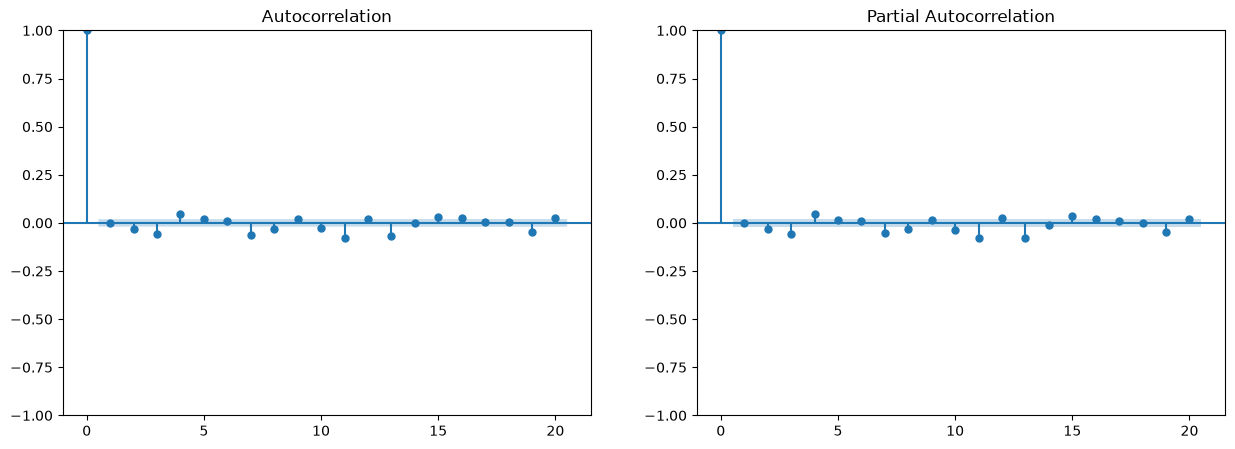

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 畫出目前殘差的 ACF 和 PACF
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(arima_resid, ax=ax[0], lags=20)
plot_pacf(arima_resid, ax=ax[1], lags=20)
plt.show()
